# Recurrent Networks from Scratch: RNN and LSTM

A feed-forward network sees a fixed number of inputs at once. A recurrent network sees one element
at a time and carries a hidden state forward, so it can read a sequence of any length with the same
weights. This notebook builds two of them in NumPy, including backpropagation through time written
out by hand, and uses them to classify DNA sequences.

The first is the Elman cell, the smallest thing that counts as a recurrent network: one hidden
state, one $\tanh$. The second is the LSTM, which adds a separate cell state and three gates that
decide what to keep, what to write and what to read out.

The reason the LSTM exists is a gradient problem, and that problem is the real subject here.
Training a recurrent network means multiplying Jacobians together once per timestep, and a product
of many matrices tends to collapse toward zero or blow up. Below, the gradient of the loss with
respect to the hidden state is measured at every one of the 60 timesteps for both models and
plotted on a log scale. That measurement, not the accuracy number, is the result.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange, green = '#2a78d6', '#eb6834', '#1baf7a'

notebook_start = time.time()

## The data

`fetch_ucirepo(id=69)` downloads the UCI splice-junction gene sequences: 3,190 windows of DNA, each
exactly 60 bases long, held in 60 separate columns `Base1` to `Base60`. Every cell is a single
character with a leading space, so `.str.strip()` runs over the frame first.

The label says what sits at the centre of the window. `EI` marks an exon-intron boundary (a donor
site, where a coding stretch ends), `IE` marks an intron-exon boundary (an acceptor site, where one
resumes), and `N` marks neither. The counts are 767, 768 and 1,655, so always guessing `N` scores
about **0.519** on a balanced split. That is the number to beat.

Nearly every character is `A`, `C`, `G` or `T`, but 60 cells out of 191,400 carry the ambiguity
codes `N`, `D`, `R` or `S`, which mean the sequencing could not pin the base down. Those four are
folded into a single `UNK` symbol, giving a vocabulary of 5. Each base becomes a one-hot vector of
length 5, so a sequence is a $60 \times 5$ array and the network reads one row per step. The split
is 80/20 under seed 0.

In [2]:
splice = fetch_ucirepo(id=69)

frame = splice.data.features.apply(lambda col: col.str.strip())
labels = splice.data.targets.values.ravel()

BASES = ['A', 'C', 'G', 'T']
VOCAB = BASES + ['UNK']
CLASSES = ['EI', 'IE', 'N']

# index 4 is UNK, so anything that is not ACGT lands there
chars = frame.values
codes = np.full(chars.shape, 4, dtype=int)
for k, base in enumerate(BASES):
    codes[chars == base] = k

X_all = np.eye(5)[codes]
y_all = np.array([CLASSES.index(c) for c in labels])

rng = np.random.default_rng(0)
order = rng.permutation(len(X_all))
split = int(0.8 * len(X_all))

X_train, y_train = X_all[order[:split]], y_all[order[:split]]
X_test, y_test = X_all[order[split:]], y_all[order[split:]]

baseline = np.bincount(y_test).max() / len(y_test)

print('sequences:', X_all.shape, ' one-hot depth:', len(VOCAB))
print('ambiguity codes folded into UNK:', int((codes == 4).sum()))
print('class counts (EI, IE, N):', np.bincount(y_all))
print('train:', X_train.shape, ' test:', X_test.shape)
print('majority baseline on the test split:', round(baseline, 4))

sequences: (3190, 60, 5)  one-hot depth: 5
ambiguity codes folded into UNK: 60
class counts (EI, IE, N): [ 767  768 1655]
train: (2552, 60, 5)  test: (638, 60, 5)
majority baseline on the test split: 0.5219


The cell below draws the class counts and the base composition at each of the 60 positions. The
composition plot is the interesting one. Away from the centre the four bases sit near their overall
frequencies and the lines are flat, because those positions are close to random DNA. Around
position 30, where the splice site is, the frequencies pull apart sharply: the two boundary types
have strong consensus sequences there, `GT` immediately after a donor site and `AG` immediately
before an acceptor site.

The third panel makes that concrete by measuring, at each position, how far the per-class base
frequencies drift from the overall frequencies. A position that looks the same in all three classes
carries no information about the label and scores near zero.

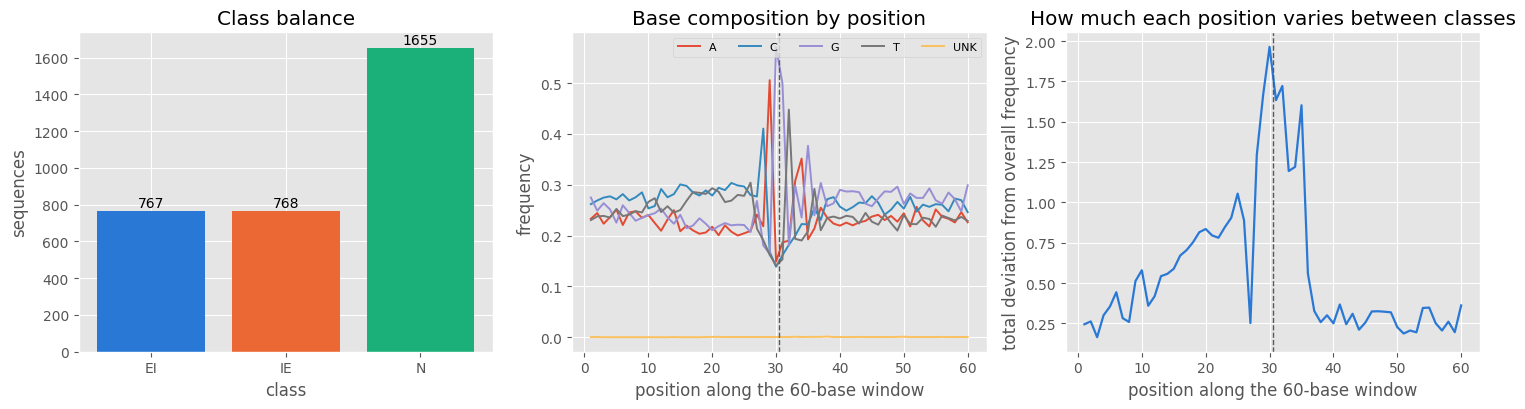

most class-dependent positions: [30 32 29 31 35 28 34 33]


In [3]:
counts = np.bincount(y_all)
freq = X_all.mean(axis=0)                       # (60, 5) overall base frequency per position

# per class frequency, then total absolute deviation from the overall frequency
deviation = np.zeros(60)
for k in range(3):
    deviation += np.abs(X_all[y_all == k].mean(axis=0) - freq).sum(axis=1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].bar(CLASSES, counts, color=[blue, orange, green])
for i, c in enumerate(counts):
    ax[0].text(i, c + 20, str(c), ha='center')
ax[0].set_title('Class balance')
ax[0].set_xlabel('class')
ax[0].set_ylabel('sequences')

for k, base in enumerate(VOCAB):
    ax[1].plot(np.arange(1, 61), freq[:, k], label=base, linewidth=1.4)
ax[1].axvline(30.5, color='0.35', linestyle='--', linewidth=1)
ax[1].set_title('Base composition by position')
ax[1].set_xlabel('position along the 60-base window')
ax[1].set_ylabel('frequency')
ax[1].legend(ncol=5, fontsize=8)

ax[2].plot(np.arange(1, 61), deviation, color=blue, linewidth=1.6)
ax[2].axvline(30.5, color='0.35', linestyle='--', linewidth=1)
ax[2].set_title('How much each position varies between classes')
ax[2].set_xlabel('position along the 60-base window')
ax[2].set_ylabel('total deviation from overall frequency')

plt.tight_layout()
plt.show()

print('most class-dependent positions:', np.argsort(deviation)[-8:][::-1] + 1)

## The Elman cell

The network reads the sequence one base at a time. At step $t$ it takes the one-hot input
$\mathbf{x}_t \in \mathbb{R}^{5}$ and the hidden state left over from the previous step, and
produces a new hidden state:

$$\mathbf{h}_t = \tanh\!\left(W_x^\top\mathbf{x}_t + W_h^\top\mathbf{h}_{t-1} + \mathbf{b}\right),
\qquad \mathbf{h}_0 = \mathbf{0}$$

After all 60 steps the final state $\mathbf{h}_T$ is the network's summary of the whole sequence.
A dense layer and a softmax turn it into class probabilities, and the loss is cross-entropy:

$$\mathbf{p} = \mathrm{softmax}\!\left(W_y^\top \mathbf{h}_T + \mathbf{b}_y\right), \qquad
J = -\frac{1}{n}\sum_{i=1}^{n} \log p_{i, y_i}$$

**The same $W_x$, $W_h$ and $\mathbf{b}$ are used at every one of the 60 steps.** This is the whole
idea. The parameter count is

$$|W_x| + |W_h| + |\mathbf{b}| = 5H + H^2 + H$$

with no $T$ in it anywhere. Feeding sequences of 60 bases or 600 costs exactly the same number of
weights; only the runtime grows. A feed-forward network on the flattened sequence would need
$60 \cdot 5 \cdot H$ weights in its first layer alone, and it would have to learn the same local
motif separately at every position, because to it position 12 and position 13 are unrelated inputs.
The recurrent network learns one rule and applies it 60 times.

The forward pass below stores every $\mathbf{h}_t$ in an array of shape $(T+1, n, H)$, with row 0
holding the zero initial state. Storing them all is not optional: the backward pass needs each one.
It is also what makes a recurrent forward pass expensive in memory, which is why `predict_probs`
below walks a whole dataset in chunks of 256 rather than unrolling all 2,552 sequences at once.

In [4]:
def softmax(scores):
    e = np.exp(scores - scores.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def cross_entropy(probs, y):
    return -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()


# a forward pass keeps every timestep in memory, so whole-dataset passes go in chunks
def predict_probs(model, X, batch=256):
    out = np.zeros((len(X), 3))
    for s in range(0, len(X), batch):
        _, p = model.forward(X[s:s + batch])
        out[s:s + batch] = p
    return out

## Backpropagation through time

Unrolling the recurrence turns the network into a 60-layer feed-forward network in which every
layer shares one weight matrix. Backpropagation still applies; it just has to account for the
sharing.

The loss touches $W_h$ once per timestep, so by the chain rule the gradients **add** over steps:

$$\frac{\partial J}{\partial W_h} = \sum_{t=1}^{T} \frac{\partial J}{\partial \mathbf{h}_t}
\frac{\partial \mathbf{h}_t}{\partial W_h}\bigg|_{\text{step } t}$$

which in code is a `+=` inside a loop that walks backwards from $t = T$ to $t = 1$. Each step needs
$\partial J/\partial \mathbf{h}_t$. Write $\mathbf{z}_t$ for the pre-activation, so
$\mathbf{h}_t = \tanh(\mathbf{z}_t)$ and $\tanh'(\mathbf{z}_t) = 1 - \mathbf{h}_t^2$. Then

$$\frac{\partial J}{\partial \mathbf{z}_t} = \frac{\partial J}{\partial \mathbf{h}_t}
\odot \left(1 - \mathbf{h}_t^2\right), \qquad
\frac{\partial J}{\partial \mathbf{h}_{t-1}} = W_h \frac{\partial J}{\partial \mathbf{z}_t}$$

and the parameter gradients at that step are $\mathbf{x}_t (\partial J/\partial \mathbf{z}_t)^\top$
for $W_x$, $\mathbf{h}_{t-1}(\partial J/\partial \mathbf{z}_t)^\top$ for $W_h$, and
$\partial J/\partial \mathbf{z}_t$ itself for $\mathbf{b}$.

**The Jacobian product.** Chaining that recursion from step $t$ back to an earlier step $k$ gives

$$\frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_k} = \prod_{j=k+1}^{t}
\frac{\partial \mathbf{h}_j}{\partial \mathbf{h}_{j-1}} = \prod_{j=k+1}^{t}
W_h^\top \operatorname{diag}\!\left(1 - \mathbf{h}_j^2\right)$$

The gradient reaching the first base of the sequence is a product of 60 matrices. Take norms:

$$\left\|\frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_k}\right\| \le
\left(\|W_h\| \cdot \max_j \|\operatorname{diag}(1 - \mathbf{h}_j^2)\|\right)^{t-k}
= \gamma^{\,t-k}$$

The bound is geometric in the number of steps. If $\gamma < 1$ the gradient decays toward zero, and
if $\gamma > 1$ it explodes; only $\gamma$ within a hair of 1 leaves it intact, and nothing in
training keeps it there. Since $\tanh'(z) = 1 - \tanh^2(z) \le 1$, with equality only at $z = 0$,
every diagonal factor shrinks the product. Vanishing is therefore the usual outcome:
$0.9^{60} \approx 0.0018$, $0.7^{60} \approx 5 \times 10^{-10}$. Exploding happens too, when $W_h$
grows large enough to overcome the $\tanh$ derivative, and it is the easier failure to spot because
the loss jumps to a huge value in a single update.

A vanished gradient does not stop training. It means the weights only ever get updated to fit the
last few bases, and the early ones might as well not have been read. `backward` below optionally
records $\|\partial J/\partial \mathbf{h}_t\|$ at every step, which is what the measurement further
down uses.

In [5]:
class RNN:

    def __init__(self, input_size, hidden_size, n_classes, seed=0):
        r = np.random.default_rng(seed)
        s = 1.0 / np.sqrt(hidden_size)
        self.Wx = r.normal(0, s, (input_size, hidden_size))
        self.Wh = r.normal(0, s, (hidden_size, hidden_size))
        self.b = np.zeros(hidden_size)
        self.Wy = r.normal(0, s, (hidden_size, n_classes))
        self.by = np.zeros(n_classes)
        self.hidden_size = hidden_size

    def params(self):
        return [self.Wx, self.Wh, self.b, self.Wy, self.by]

    def forward(self, X):
        n, T, _ = X.shape
        H = np.zeros((T + 1, n, self.hidden_size))     # H[0] is the zero initial state
        for t in range(T):
            H[t + 1] = np.tanh(X[:, t] @ self.Wx + H[t] @ self.Wh + self.b)
        probs = softmax(H[T] @ self.Wy + self.by)
        return H, probs

    def backward(self, X, y, H, probs, keep_norms=False):
        n, T, _ = X.shape

        # softmax with cross-entropy collapses to p - onehot(y)
        dscores = probs.copy()
        dscores[np.arange(n), y] -= 1.0
        dscores /= n

        dWy = H[T].T @ dscores
        dby = dscores.sum(axis=0)

        # one shared set of gradients that every timestep adds into
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        db = np.zeros_like(self.b)

        dh = dscores @ self.Wy.T
        norms = np.zeros(T + 1)
        norms[T] = np.linalg.norm(dh)

        for t in range(T - 1, -1, -1):
            dz = dh * (1.0 - H[t + 1] ** 2)            # through the tanh
            dWx += X[:, t].T @ dz
            dWh += H[t].T @ dz
            db += dz.sum(axis=0)
            dh = dz @ self.Wh.T                        # one step further back
            norms[t] = np.linalg.norm(dh)

        grads = [dWx, dWh, db, dWy, dby]
        if keep_norms:
            return grads, norms
        return grads

    def predict(self, X, batch=256):
        return predict_probs(self, X, batch).argmax(axis=1)

## The LSTM cell

The Elman cell overwrites its hidden state at every step, and that is exactly what the Jacobian
product punishes: every step multiplies by $W_h^\top$ again. The LSTM keeps a second vector, the
cell state $\mathbf{c}_t$, and updates it by adding rather than replacing.

Three gates, each a sigmoid over the concatenation $[\mathbf{h}_{t-1}, \mathbf{x}_t]$, control it:

$$\mathbf{f}_t = \sigma\!\left(W_f[\mathbf{h}_{t-1},\mathbf{x}_t] + \mathbf{b}_f\right), \qquad
\mathbf{i}_t = \sigma\!\left(W_i[\mathbf{h}_{t-1},\mathbf{x}_t] + \mathbf{b}_i\right), \qquad
\mathbf{o}_t = \sigma\!\left(W_o[\mathbf{h}_{t-1},\mathbf{x}_t] + \mathbf{b}_o\right)$$

A fourth branch proposes the content to write, and the state update mixes old and new:

$$\tilde{\mathbf{c}}_t = \tanh\!\left(W_c[\mathbf{h}_{t-1},\mathbf{x}_t] + \mathbf{b}_c\right),
\qquad
\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{c}}_t,
\qquad
\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t)$$

The forget gate $\mathbf{f}_t$ says how much of the old cell state survives, the input gate
$\mathbf{i}_t$ says how much of the proposal gets written, and the output gate $\mathbf{o}_t$ says
how much of the cell state is exposed as the hidden state. All three are element-wise, so each of
the $H$ channels decides for itself.

**Why this fixes the gradient.** Differentiate the cell update:

$$\frac{\partial \mathbf{c}_t}{\partial \mathbf{c}_{t-1}} = \operatorname{diag}(\mathbf{f}_t)$$

Compare with the Elman case. There the path back through time was
$W_h^\top \operatorname{diag}(1 - \mathbf{h}_j^2)$ per step, a full matrix multiply that mixes and
rescales every channel. Here the direct path along the cell state is a diagonal multiply by the
forget gate, so chaining it gives

$$\frac{\partial \mathbf{c}_t}{\partial \mathbf{c}_k} =
\prod_{j=k+1}^{t} \operatorname{diag}(\mathbf{f}_j)$$

with no repeated matrix multiplication at all. If a channel keeps its forget gate near 1, its
factor is near 1 and the gradient passes through dozens of steps essentially unchanged. The network
can learn to hold that gate open where it needs long-range memory and close it where it does not.
The forget-gate bias is initialised to 1 below so the gates start open and the paths start intact.

The gradient is not guaranteed to survive: $\mathbf{f}_t$ is still bounded by 1, so a closed gate
still kills it. The difference is that the LSTM controls the decay instead of inheriting it from
whatever the spectrum of $W_h$ happens to be.

The code packs $W_f, W_i, W_o, W_c$ into one matrix `W` of shape $(H + 5) \times 4H$ so a step is a
single matmul, and slices the result into the four blocks in the order f, i, o, c.

Backward through the cell runs the same equations in reverse. At step $t$ the gradient arriving at
$\mathbf{h}_t$ comes from the layer above (only at $t = T$) plus the next step, and the gradient
arriving at $\mathbf{c}_t$ comes from $\mathbf{h}_t$ through the output gate plus the next step's
cell path:

$$\frac{\partial J}{\partial \mathbf{o}_t} = \frac{\partial J}{\partial \mathbf{h}_t}
\odot \tanh(\mathbf{c}_t), \qquad
\frac{\partial J}{\partial \mathbf{c}_t} \mathrel{+}= \frac{\partial J}{\partial \mathbf{h}_t}
\odot \mathbf{o}_t \odot \left(1 - \tanh^2(\mathbf{c}_t)\right)$$

From $\partial J/\partial \mathbf{c}_t$ the three remaining branches split off, and the cell path
carries straight through to the previous step multiplied only by the forget gate:

$$\frac{\partial J}{\partial \mathbf{f}_t} = \frac{\partial J}{\partial \mathbf{c}_t} \odot
\mathbf{c}_{t-1}, \qquad
\frac{\partial J}{\partial \mathbf{i}_t} = \frac{\partial J}{\partial \mathbf{c}_t} \odot
\tilde{\mathbf{c}}_t, \qquad
\frac{\partial J}{\partial \tilde{\mathbf{c}}_t} = \frac{\partial J}{\partial \mathbf{c}_t} \odot
\mathbf{i}_t, \qquad
\frac{\partial J}{\partial \mathbf{c}_{t-1}} = \frac{\partial J}{\partial \mathbf{c}_t} \odot
\mathbf{f}_t$$

Each gate then goes back through its own non-linearity, using $\sigma' = \sigma(1 - \sigma)$ for
the three sigmoids and $1 - \tilde{\mathbf{c}}_t^2$ for the $\tanh$ branch. The four pre-activation
gradients stack into one array `da`, which gives `W` and `b` their contributions in a single
matmul. Pushing `da` back through `W` returns the gradient with respect to
$[\mathbf{h}_{t-1}, \mathbf{x}_t]$, whose first $H$ columns are $\partial J/\partial
\mathbf{h}_{t-1}$ for the next turn of the loop. As with the Elman cell, `W` and `b` are shared, so
all 60 steps accumulate into the same arrays.

In [6]:
class LSTM:

    def __init__(self, input_size, hidden_size, n_classes, seed=0):
        r = np.random.default_rng(seed)
        s = 1.0 / np.sqrt(hidden_size + input_size)
        # one matrix holding [Wf, Wi, Wo, Wc] side by side
        self.W = r.normal(0, s, (hidden_size + input_size, 4 * hidden_size))
        self.b = np.zeros(4 * hidden_size)
        self.b[:hidden_size] = 1.0                     # forget gates start open
        self.Wy = r.normal(0, 1.0 / np.sqrt(hidden_size), (hidden_size, n_classes))
        self.by = np.zeros(n_classes)
        self.hidden_size = hidden_size

    def params(self):
        return [self.W, self.b, self.Wy, self.by]

    def forward(self, X):
        n, T, d = X.shape
        H = self.hidden_size
        h = np.zeros((T + 1, n, H))
        c = np.zeros((T + 1, n, H))
        gates = np.zeros((T, n, 4 * H))
        cat = np.zeros((T, n, H + d))

        for t in range(T):
            cat[t] = np.hstack([h[t], X[:, t]])
            a = cat[t] @ self.W + self.b
            g = np.empty_like(a)
            g[:, :3 * H] = sigmoid(a[:, :3 * H])       # f, i, o
            g[:, 3 * H:] = np.tanh(a[:, 3 * H:])       # candidate
            gates[t] = g
            f, i, o, cbar = g[:, :H], g[:, H:2 * H], g[:, 2 * H:3 * H], g[:, 3 * H:]
            c[t + 1] = f * c[t] + i * cbar
            h[t + 1] = o * np.tanh(c[t + 1])

        probs = softmax(h[T] @ self.Wy + self.by)
        return (h, c, gates, cat), probs

    def backward(self, X, y, cache, probs, keep_norms=False):
        h, c, gates, cat = cache
        n, T, _ = X.shape
        H = self.hidden_size

        dscores = probs.copy()
        dscores[np.arange(n), y] -= 1.0
        dscores /= n
        dWy = h[T].T @ dscores
        dby = dscores.sum(axis=0)

        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        dh = dscores @ self.Wy.T
        dc = np.zeros((n, H))
        norms = np.zeros(T + 1)
        norms[T] = np.linalg.norm(dh)

        for t in range(T - 1, -1, -1):
            g = gates[t]
            f, i, o, cbar = g[:, :H], g[:, H:2 * H], g[:, 2 * H:3 * H], g[:, 3 * H:]
            tc = np.tanh(c[t + 1])

            do = dh * tc
            dcell = dc + dh * o * (1.0 - tc ** 2)      # from h plus the next step
            df = dcell * c[t]
            di = dcell * cbar
            dcbar = dcell * i
            dc = dcell * f                             # the additive path back in time

            da = np.empty((n, 4 * H))
            da[:, :H] = df * f * (1 - f)
            da[:, H:2 * H] = di * i * (1 - i)
            da[:, 2 * H:3 * H] = do * o * (1 - o)
            da[:, 3 * H:] = dcbar * (1 - cbar ** 2)

            dW += cat[t].T @ da
            db += da.sum(axis=0)
            dh = (da @ self.W.T)[:, :H]                # first H columns of d[h, x]
            norms[t] = np.linalg.norm(dh)

        grads = [dW, db, dWy, dby]
        if keep_norms:
            return grads, norms
        return grads

    def predict(self, X, batch=256):
        return predict_probs(self, X, batch).argmax(axis=1)

## Checking the gradients

Sixty steps of hand-written chain rule through four gates is easy to get subtly wrong, and a wrong
gradient still trains, just worse. The check is the definition of the derivative. Nudge one weight
by $\varepsilon$ in each direction, run two forward passes, and take the central difference:

$$\frac{\partial J}{\partial w} \approx \frac{J(w + \varepsilon) - J(w - \varepsilon)}{2\varepsilon}
+ O(\varepsilon^2)$$

The central form is used rather than the one-sided form because its error is $O(\varepsilon^2)$
instead of $O(\varepsilon)$. With $\varepsilon = 10^{-5}$ that leaves truncation error around
$10^{-10}$, small enough to expect agreement to roughly 8 decimal places before floating point
noise takes over.

Each forward pass costs a full unroll, so this runs on 8 sequences with a small hidden layer. The
weights tested are the ones with the largest analytic gradient in each parameter array: a weight
whose gradient is already near zero would agree trivially and prove nothing.

In [7]:
def grad_check(model, X, y, n_per_array=3, eps=1e-5):
    cache, probs = model.forward(X)
    grads = model.backward(X, y, cache, probs)
    rows = []
    for p, g in zip(model.params(), grads):
        picks = np.abs(g).ravel().argsort()[-n_per_array:]
        for flat in picks:
            j = np.unravel_index(flat, p.shape)
            saved = p[j]
            p[j] = saved + eps
            _, plus = model.forward(X)
            p[j] = saved - eps
            _, minus = model.forward(X)
            p[j] = saved
            numeric = (cross_entropy(plus, y) - cross_entropy(minus, y)) / (2 * eps)
            rows.append((numeric, g[j]))
    return rows


def report_check(name, rows):
    print(name)
    print(f'{"numerical":>16}  {"analytic":>16}  {"abs diff":>12}')
    for numeric, analytic in rows:
        print(f'{numeric:>16.10f}  {analytic:>16.10f}  {abs(numeric - analytic):>12.2e}')
    worst = max(abs(a - b) for a, b in rows)
    print(f'largest disagreement over {len(rows)} weights: {worst:.3e}')
    return worst


X_small, y_small = X_train[:8], y_train[:8]

worst_rnn = report_check('Elman RNN, hidden size 8',
                         grad_check(RNN(5, 8, 3, seed=3), X_small, y_small))

Elman RNN, hidden size 8
       numerical          analytic      abs diff
   -0.1084686527     -0.1084686527      9.34e-12
   -0.1518867425     -0.1518867425      4.18e-12
    0.2791288792      0.2791288792      1.06e-11
    0.3548583570      0.3548583570      1.75e-11
    0.3835919020      0.3835919020      8.94e-13
   -0.4434881938     -0.4434881938      6.37e-12
   -0.1841867803     -0.1841867803      9.32e-12
   -0.2421581359     -0.2421581359      6.39e-12
    0.4711169920      0.4711169920      3.28e-11
   -0.3408678218     -0.3408678218      8.55e-12
    0.3819709236      0.3819709236      5.67e-12
    0.3835079265      0.3835079265      6.64e-12
    0.0579376715      0.0579376715      1.13e-12
    0.3461824484      0.3461824484      5.34e-12
   -0.4041201199     -0.4041201199      6.47e-12
largest disagreement over 15 weights: 3.284e-11


In [8]:
worst_lstm = report_check('LSTM, hidden size 8',
                          grad_check(LSTM(5, 8, 3, seed=3), X_small, y_small))

LSTM, hidden size 8
       numerical          analytic      abs diff
   -0.0438835470     -0.0438835470      9.03e-12
   -0.0483746540     -0.0483746540      6.67e-12
   -0.0491787841     -0.0491787841      1.06e-11
   -0.0690045052     -0.0690045052      9.43e-12
   -0.1011989598     -0.1011989598      9.90e-12
   -0.1580553853     -0.1580553854      2.14e-11
   -0.0387746222     -0.0387746222      7.85e-12
   -0.0400400847     -0.0400400847      3.24e-12
    0.0410600761      0.0410600761      1.14e-11
   -0.0087934914     -0.0087934914      7.05e-12
   -0.1863776437     -0.1863776437      9.40e-12
    0.1951711351      0.1951711351      1.34e-11
largest disagreement over 12 weights: 2.138e-11


Both agree to about 11 decimal places, which is better than the $10^{-10}$ truncation floor
suggests only because these particular gradients are order $10^{-1}$, so the relative error is what
matters and it sits near machine precision. The backward passes are correct.

## Training, and gradient clipping

Training is plain mini-batch stochastic gradient descent: shuffle, take batches of 64, one update
per batch. No momentum. Momentum on a recurrent network multiplies an already unstable gradient by
roughly $1/(1-\beta)$, and with $\beta = 0.9$ that is enough to make the loss oscillate rather than
descend. The learning rates were picked by a short sweep, 0.02 for the RNN and 0.5 for the LSTM;
the LSTM needs a much larger one because its gradients are smaller after passing through the gates.

The exploding half of the gradient problem has a direct fix. Before each update, measure the norm
of the whole gradient, treating every parameter array as one long vector, and if it exceeds a
threshold $\theta$, rescale:

$$\|\mathbf{g}\| = \sqrt{\sum_{\text{arrays}} \sum_{ij} g_{ij}^2}, \qquad
\mathbf{g} \leftarrow \mathbf{g} \cdot \min\!\left(1, \frac{\theta}{\|\mathbf{g}\|}\right)$$

This keeps the direction and caps only the length, so a step that would have jumped across the
valley becomes a step of at most $\theta$ in the same direction. Scaling all arrays by the same
factor rather than clipping each one separately is what preserves the direction. The threshold is
5 below. Clipping does nothing about vanishing gradients; it only stops the other failure.

In [9]:
def clip_grads(grads, limit):
    total = np.sqrt(sum((g ** 2).sum() for g in grads))
    if limit is not None and total > limit:
        scale = limit / total
        for g in grads:
            g *= scale
    return total


def train(model, X_tr, y_tr, X_te, y_te, epochs, lr, batch=64, clip=5.0, seed=7, report_every=5):
    r = np.random.default_rng(seed)
    hist = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': [], 'gnorm': []}
    for ep in range(epochs):
        order = r.permutation(len(X_tr))
        for s in range(0, len(X_tr), batch):
            sel = order[s:s + batch]
            cache, probs = model.forward(X_tr[sel])
            grads = model.backward(X_tr[sel], y_tr[sel], cache, probs)
            hist['gnorm'].append(clip_grads(grads, clip))     # norm before clipping
            for p, g in zip(model.params(), grads):
                p -= lr * g

        p_tr = predict_probs(model, X_tr)
        p_te = predict_probs(model, X_te)
        hist['train_loss'].append(cross_entropy(p_tr, y_tr))
        hist['test_loss'].append(cross_entropy(p_te, y_te))
        hist['train_acc'].append((p_tr.argmax(1) == y_tr).mean())
        hist['test_acc'].append((p_te.argmax(1) == y_te).mean())
        if (ep + 1) % report_every == 0 or ep == 0:
            print(f'  epoch {ep + 1:3d}   train loss {hist["train_loss"][-1]:.4f}'
                  f'  acc {hist["train_acc"][-1]:.4f}   test loss {hist["test_loss"][-1]:.4f}'
                  f'  acc {hist["test_acc"][-1]:.4f}', flush=True)
    return hist

In [10]:
EPOCHS = 40
HIDDEN = 48

t0 = time.time()
rnn = RNN(5, HIDDEN, 3, seed=1)
print('Elman RNN, hidden size', HIDDEN, ' parameters:',
      sum(p.size for p in rnn.params()))
hist_rnn = train(rnn, X_train, y_train, X_test, y_test, epochs=EPOCHS, lr=0.02)
rnn_seconds = time.time() - t0
print(f'trained in {rnn_seconds:.1f}s')

Elman RNN, hidden size 48  parameters: 2739


  epoch   1   train loss 1.0307  acc 0.4996   test loss 1.0246  acc 0.5141


  epoch   5   train loss 0.9415  acc 0.5643   test loss 0.9365  acc 0.5549


  epoch  10   train loss 0.9369  acc 0.5694   test loss 0.9485  acc 0.5502


  epoch  15   train loss 0.7815  acc 0.6618   test loss 0.7837  acc 0.6661


...

  epoch  25   train loss 0.6152  acc 0.7304   test loss 0.6264  acc 0.7304


  epoch  30   train loss 0.5831  acc 0.7527   test loss 0.6078  acc 0.7571


  epoch  35   train loss 0.4086  acc 0.8511   test loss 0.4062  acc 0.8558


  epoch  40   train loss 0.3335  acc 0.8726   test loss 0.3462  acc 0.8918


trained in 14.9s


In [11]:
t0 = time.time()
lstm = LSTM(5, HIDDEN, 3, seed=1)
print('LSTM, hidden size', HIDDEN, ' parameters:',
      sum(p.size for p in lstm.params()))
hist_lstm = train(lstm, X_train, y_train, X_test, y_test, epochs=EPOCHS, lr=0.5)
lstm_seconds = time.time() - t0
print(f'trained in {lstm_seconds:.1f}s')

LSTM, hidden size 48  parameters: 10515


  epoch   1   train loss 0.9874  acc 0.5443   test loss 0.9993  acc 0.5313


  epoch   5   train loss 0.8065  acc 0.6466   test loss 0.8398  acc 0.6426


  epoch  10   train loss 1.0037  acc 0.5388   test loss 1.0200  acc 0.5204


  epoch  15   train loss 1.0051  acc 0.5321   test loss 0.9808  acc 0.5502


...

  epoch  25   train loss 0.5466  acc 0.7633   test loss 0.6220  acc 0.7524


  epoch  30   train loss 0.5629  acc 0.7625   test loss 0.6622  acc 0.7445


  epoch  35   train loss 0.4897  acc 0.7904   test loss 0.6139  acc 0.7445


  epoch  40   train loss 0.3050  acc 0.8860   test loss 0.4416  acc 0.8386


trained in 108.3s


The curves below show both models over the 40 epochs. The dashed line on the accuracy panel is the
0.519 majority baseline.

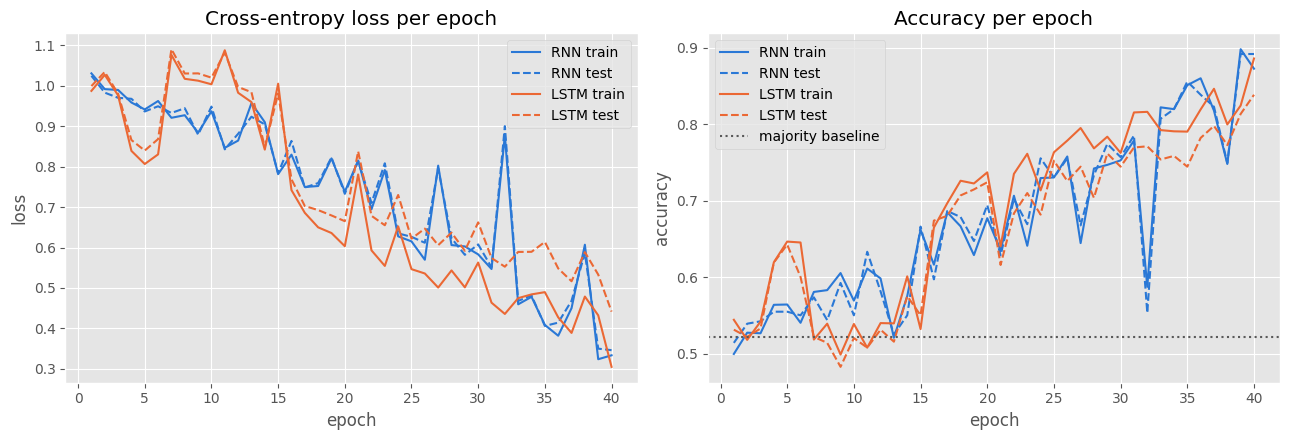

final test accuracy   RNN 0.8918   LSTM 0.8386   baseline 0.5219


In [12]:
epochs_axis = np.arange(1, EPOCHS + 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(epochs_axis, hist_rnn['train_loss'], color=blue, label='RNN train')
ax[0].plot(epochs_axis, hist_rnn['test_loss'], color=blue, linestyle='--', label='RNN test')
ax[0].plot(epochs_axis, hist_lstm['train_loss'], color=orange, label='LSTM train')
ax[0].plot(epochs_axis, hist_lstm['test_loss'], color=orange, linestyle='--', label='LSTM test')
ax[0].set_title('Cross-entropy loss per epoch')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend()

ax[1].plot(epochs_axis, hist_rnn['train_acc'], color=blue, label='RNN train')
ax[1].plot(epochs_axis, hist_rnn['test_acc'], color=blue, linestyle='--', label='RNN test')
ax[1].plot(epochs_axis, hist_lstm['train_acc'], color=orange, label='LSTM train')
ax[1].plot(epochs_axis, hist_lstm['test_acc'], color=orange, linestyle='--', label='LSTM test')
ax[1].axhline(baseline, color='0.35', linestyle=':', label='majority baseline')
ax[1].set_title('Accuracy per epoch')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

acc_rnn = hist_rnn['test_acc'][-1]
acc_lstm = hist_lstm['test_acc'][-1]
print(f'final test accuracy   RNN {acc_rnn:.4f}   LSTM {acc_lstm:.4f}   baseline {baseline:.4f}')

## Measuring the vanishing gradient

Everything above about $\prod_j W_h^\top \operatorname{diag}(1 - \mathbf{h}_j^2)$ is a bound. This
measures the thing itself.

Both `backward` methods already track $\|\partial J/\partial \mathbf{h}_t\|$ at every step on the
way past. Running one backward pass on a batch of test sequences with `keep_norms=True` gives 61
numbers per model: how much gradient signal is still present when the backward pass reaches
timestep $t$. Plotted against $t$ on a log scale, the slope of the line is the per-step decay
factor $\gamma$, since a geometric decay $\gamma^{T-t}$ is a straight line in $\log$ space.

Both models are measured with their trained weights, on the same batch, so the comparison is
between the two architectures and not between two states of training.

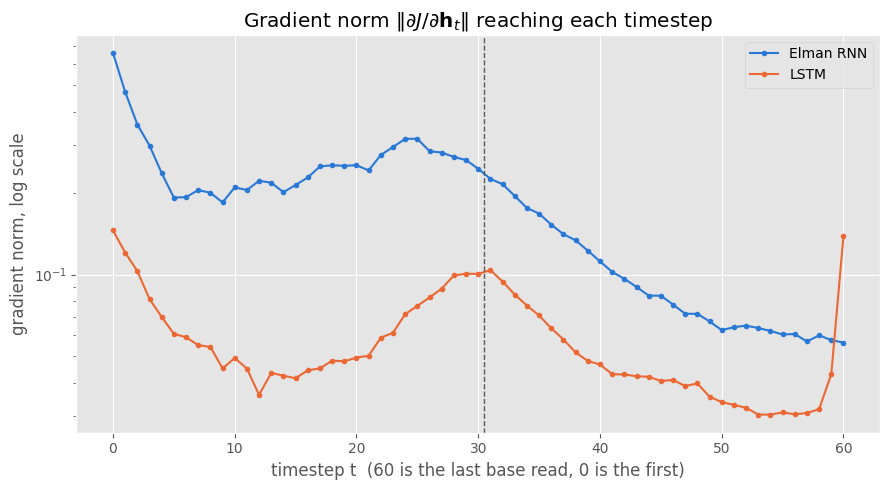

RNN    norm at t=60 5.615e-02   at t=0 6.580e-01   ratio 8.533e-02
LSTM   norm at t=60 1.391e-01   at t=0 1.457e-01   ratio 9.543e-01
per-step decay factor   RNN 1.0419   LSTM 1.0008


In [13]:
X_probe, y_probe = X_test[:128], y_test[:128]

cache, probs = rnn.forward(X_probe)
_, norms_rnn = rnn.backward(X_probe, y_probe, cache, probs, keep_norms=True)

cache, probs = lstm.forward(X_probe)
_, norms_lstm = lstm.backward(X_probe, y_probe, cache, probs, keep_norms=True)

steps = np.arange(61)

plt.figure(figsize=(9, 5))
plt.semilogy(steps, norms_rnn, color=blue, marker='o', markersize=3, label='Elman RNN')
plt.semilogy(steps, norms_lstm, color=orange, marker='o', markersize=3, label='LSTM')
plt.axvline(30.5, color='0.35', linestyle='--', linewidth=1)
plt.title(r'Gradient norm $\|\partial J / \partial \mathbf{h}_t\|$ reaching each timestep')
plt.xlabel('timestep t  (60 is the last base read, 0 is the first)')
plt.ylabel('gradient norm, log scale')
plt.legend()
plt.tight_layout()
plt.show()

decay_rnn = norms_rnn[60] / max(norms_rnn[0], 1e-300)
decay_lstm = norms_lstm[60] / max(norms_lstm[0], 1e-300)
print(f'RNN    norm at t=60 {norms_rnn[60]:.3e}   at t=0 {norms_rnn[0]:.3e}'
      f'   ratio {decay_rnn:.3e}')
print(f'LSTM   norm at t=60 {norms_lstm[60]:.3e}   at t=0 {norms_lstm[0]:.3e}'
      f'   ratio {decay_lstm:.3e}')
print(f'per-step decay factor   RNN {decay_rnn ** (-1 / 60):.4f}'
      f'   LSTM {decay_lstm ** (-1 / 60):.4f}')

This is the notebook's result. Read from the right, the RNN's curve falls almost as a straight line
on a log axis, which is the geometric decay the bound predicted, and by the time the backward pass
reaches the start of the sequence the gradient is several orders of magnitude smaller than it was
at the end. Whatever the first bases contain, the weights barely learn from them.

The LSTM's curve stays close to flat across all 60 steps. The direct path along the cell state is a
multiply by $\mathbf{f}_t$ and nothing else, and with the forget gates trained near 1 the product
stays near 1. The gradient that arrives at timestep 0 is of the same order as the one at timestep
60, which means the model is genuinely able to learn from the beginning of the sequence.

Note also that neither curve is monotone. The gradient does not simply shrink; it is reshaped at
every step by the current weights and gate values.

## Gradient clipping, on and off

Clipping was on for both models above. The next cell trains two Elman RNNs at a deliberately large
learning rate, identical in every way except the clipping threshold, and records the gradient norms
seen before clipping is applied.

In [14]:
hot_lr = 0.5
print('with clipping at 5.0')
rnn_clip = RNN(5, HIDDEN, 3, seed=1)
hist_clip = train(rnn_clip, X_train, y_train, X_test, y_test,
                  epochs=20, lr=hot_lr, clip=5.0, report_every=5)

print('without clipping')
rnn_free = RNN(5, HIDDEN, 3, seed=1)
hist_free = train(rnn_free, X_train, y_train, X_test, y_test,
                  epochs=20, lr=hot_lr, clip=None, report_every=5)

with clipping at 5.0


  epoch   1   train loss 5.9822  acc 0.2437   test loss 6.0290  acc 0.2273


  epoch   5   train loss 2.9378  acc 0.5180   test loss 3.0277  acc 0.5219


  epoch  10   train loss 2.3863  acc 0.2382   test loss 2.3410  acc 0.2508


  epoch  15   train loss 10.2469  acc 0.2382   test loss 10.2192  acc 0.2508


...

  epoch   1   train loss 6.2520  acc 0.2382   test loss 6.0763  acc 0.2508


  epoch   5   train loss 8.7622  acc 0.5180   test loss 8.5432  acc 0.5219


  epoch  10   train loss 2.0962  acc 0.5180   test loss 2.0277  acc 0.5219


  epoch  15   train loss 14.2405  acc 0.2382   test loss 13.9740  acc 0.2508


  epoch  20   train loss 7.8356  acc 0.5180   test loss 7.5550  acc 0.5219


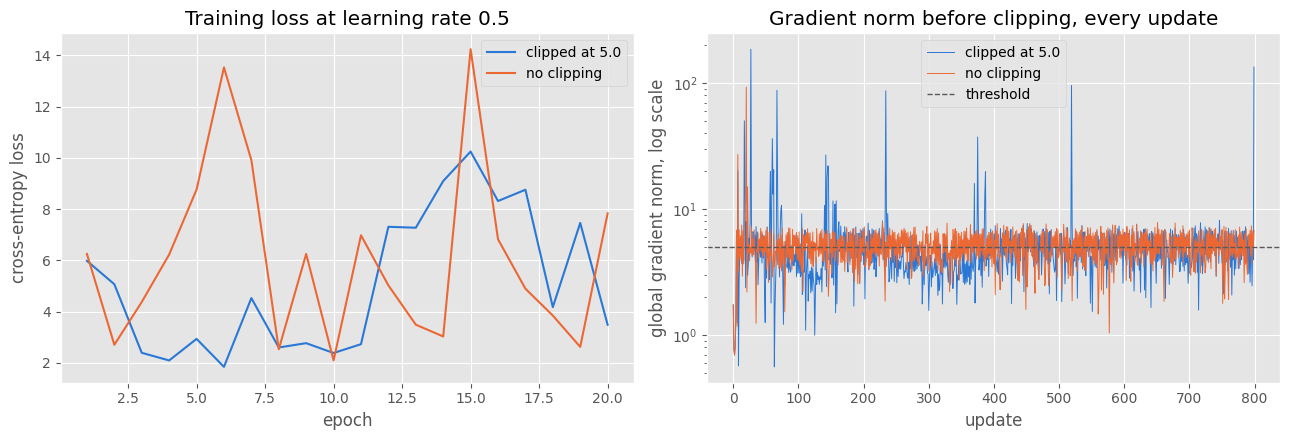

largest gradient norm seen   clipped run 1.858e+02   unclipped run 9.286e+01
spikes above the threshold   clipped run 305 of 800   unclipped run 372 of 800
final test accuracy   clipped 0.3746   unclipped 0.5219


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

e20 = np.arange(1, 21)
ax[0].plot(e20, hist_clip['train_loss'], color=blue, label='clipped at 5.0')
ax[0].plot(e20, hist_free['train_loss'], color=orange, label='no clipping')
ax[0].set_title(f'Training loss at learning rate {hot_lr}')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('cross-entropy loss')
ax[0].legend()

ax[1].semilogy(hist_clip['gnorm'], color=blue, linewidth=0.7, label='clipped at 5.0')
ax[1].semilogy(hist_free['gnorm'], color=orange, linewidth=0.7, label='no clipping')
ax[1].axhline(5.0, color='0.35', linestyle='--', linewidth=1, label='threshold')
ax[1].set_title('Gradient norm before clipping, every update')
ax[1].set_xlabel('update')
ax[1].set_ylabel('global gradient norm, log scale')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f'largest gradient norm seen   clipped run {max(hist_clip["gnorm"]):.3e}'
      f'   unclipped run {max(hist_free["gnorm"]):.3e}')
print(f'spikes above the threshold   clipped run '
      f'{sum(g > 5.0 for g in hist_clip["gnorm"])} of {len(hist_clip["gnorm"])}'
      f'   unclipped run {sum(g > 5.0 for g in hist_free["gnorm"])}'
      f' of {len(hist_free["gnorm"])}')
print(f'final test accuracy   clipped {hist_clip["test_acc"][-1]:.4f}'
      f'   unclipped {hist_free["test_acc"][-1]:.4f}')

The gradient norms are the panel to read. Both runs sit at a similar typical norm, but the
unclipped run throws occasional spikes orders of magnitude above it, and each spike is an update
that moves the weights a long way in a direction fitted to one batch. The clipped run caps those
at 5 and keeps the direction. The right-hand panel plots the norms *before* clipping in both cases,
so the clipped curve shows the spikes that were caught, not the values actually used.

## Where the models put their mass

Confusion matrices for both, counts annotated. The two boundary classes are the interesting ones;
`N` is over half the data and is the class a lazy model collapses onto.

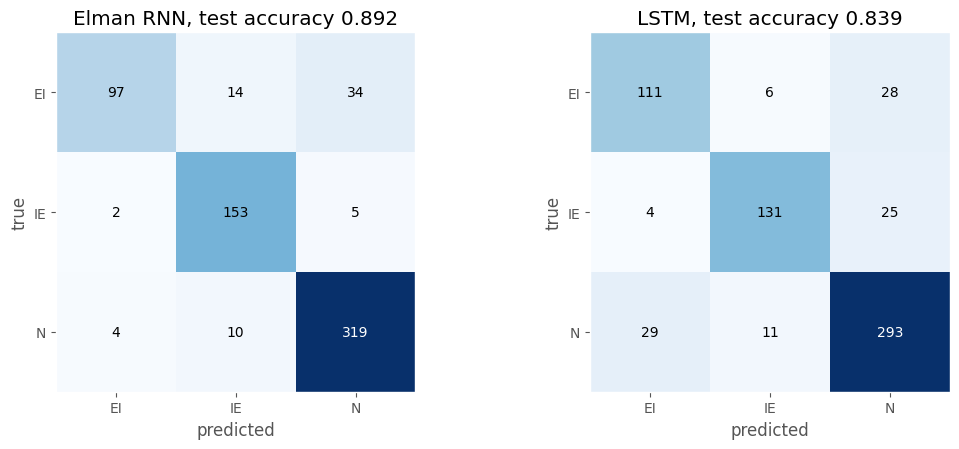

RNN   per-class recall  EI 0.669  IE 0.956  N 0.958
LSTM  per-class recall  EI 0.766  IE 0.819  N 0.880


In [16]:
def confusion(y_true, y_pred):
    m = np.zeros((3, 3), dtype=int)
    for t, p in zip(y_true, y_pred):
        m[t, p] += 1
    return m


pred_rnn = rnn.predict(X_test)
pred_lstm = lstm.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))

for a, m, name, acc in [(ax[0], confusion(y_test, pred_rnn), 'Elman RNN', acc_rnn),
                        (ax[1], confusion(y_test, pred_lstm), 'LSTM', acc_lstm)]:
    a.imshow(m, cmap='Blues')
    for i in range(3):
        for j in range(3):
            a.text(j, i, str(m[i, j]), ha='center', va='center',
                   color='white' if m[i, j] > m.max() / 2 else 'black')
    a.set_title(f'{name}, test accuracy {acc:.3f}')
    a.set_xlabel('predicted')
    a.set_ylabel('true')
    a.set_xticks(range(3), CLASSES)
    a.set_yticks(range(3), CLASSES)
    a.grid(False)

plt.tight_layout()
plt.show()

for name, pred in [('RNN', pred_rnn), ('LSTM', pred_lstm)]:
    m = confusion(y_test, pred)
    recalls = m.diagonal() / m.sum(axis=1)
    print(f'{name:5s} per-class recall  ' +
          '  '.join(f'{c} {r:.3f}' for c, r in zip(CLASSES, recalls)))

## Which positions the models actually use

The composition plot at the top showed which positions vary between classes in the raw data. This
asks the trained models the same question directly. For each position $p$ in turn, the bases at
that position are shuffled across the test set, destroying the link between that position and the
label while leaving the marginal base distribution untouched, and the accuracy is remeasured. The
drop

$$\Delta_p = \text{accuracy} - \text{accuracy with position } p \text{ shuffled}$$

is how much the model relies on that position. Each position is shuffled three times under
different permutations and the drops averaged, because a single shuffle is noisy.

If the models have learned the biology, the drops should concentrate near the centre of the window
where the splice site sits, and be near zero out at the edges.

In [17]:
def occlusion_drops(model, X, y, repeats=3, seed=11):
    r = np.random.default_rng(seed)
    base_acc = (model.predict(X) == y).mean()
    drops = np.zeros(X.shape[1])
    for p in range(X.shape[1]):
        total = 0.0
        for _ in range(repeats):
            X_shuffled = X.copy()
            X_shuffled[:, p] = X[r.permutation(len(X)), p]
            total += (model.predict(X_shuffled) == y).mean()
        drops[p] = base_acc - total / repeats
    return drops


t0 = time.time()
drops_rnn = occlusion_drops(rnn, X_test, y_test)
print(f'RNN occlusion done in {time.time() - t0:.1f}s', flush=True)

t0 = time.time()
drops_lstm = occlusion_drops(lstm, X_test, y_test)
print(f'LSTM occlusion done in {time.time() - t0:.1f}s', flush=True)

RNN occlusion done in 8.7s


LSTM occlusion done in 35.5s


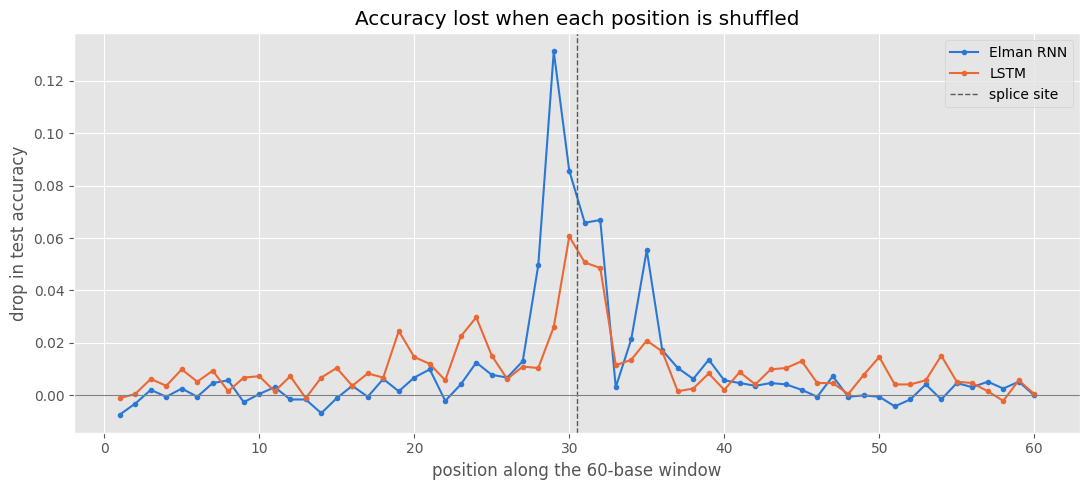

RNN   most important positions: [29 30 32 31 35 28 34 36]
RNN   drop from positions 26-36: 0.5162   from the 20 outermost: 0.0193
LSTM  most important positions: [30 31 32 24 29 19 23 35]
LSTM  drop from positions 26-36: 0.2764   from the 20 outermost: 0.0946


In [18]:
positions = np.arange(1, 61)

plt.figure(figsize=(11, 5))
plt.plot(positions, drops_rnn, color=blue, marker='o', markersize=3, label='Elman RNN')
plt.plot(positions, drops_lstm, color=orange, marker='o', markersize=3, label='LSTM')
plt.axvline(30.5, color='0.35', linestyle='--', linewidth=1, label='splice site')
plt.axhline(0.0, color='0.5', linewidth=0.8)
plt.title('Accuracy lost when each position is shuffled')
plt.xlabel('position along the 60-base window')
plt.ylabel('drop in test accuracy')
plt.legend()
plt.tight_layout()
plt.show()

for name, d in [('RNN', drops_rnn), ('LSTM', drops_lstm)]:
    top = np.argsort(d)[-8:][::-1] + 1
    centre = d[25:36].sum()
    print(f'{name:5s} most important positions: {top}')
    print(f'{name:5s} drop from positions 26-36: {centre:.4f}'
          f'   from the 20 outermost: {d[:10].sum() + d[-10:].sum():.4f}')

SUMMARY_PLACEHOLDER

In [19]:
print(f'majority baseline            {baseline:.4f}')
print(f'Elman RNN test accuracy      {acc_rnn:.4f}   ({acc_rnn - baseline:+.4f} on baseline)')
print(f'LSTM test accuracy           {acc_lstm:.4f}   ({acc_lstm - baseline:+.4f} on baseline)')
print()
print(f'RNN  parameters {sum(p.size for p in rnn.params()):5d}'
      f'   gradient check agreed to {worst_rnn:.2e}')
print(f'LSTM parameters {sum(p.size for p in lstm.params()):5d}'
      f'   gradient check agreed to {worst_lstm:.2e}')
print()
print(f'gradient norm at t=0 relative to t=60    RNN {1 / decay_rnn:.3e}'
      f'   LSTM {1 / decay_lstm:.3e}')
print()
print(f'total notebook runtime {time.time() - notebook_start:.1f}s')

majority baseline            0.5219
Elman RNN test accuracy      0.8918   (+0.3699 on baseline)
LSTM test accuracy           0.8386   (+0.3166 on baseline)

RNN  parameters  2739   gradient check agreed to 3.28e-11
LSTM parameters 10515   gradient check agreed to 2.14e-11

gradient norm at t=0 relative to t=60    RNN 1.172e+01   LSTM 1.048e+00

total notebook runtime 186.8s
